In [1]:
import scanpy as sc
import pandas as pd
import pickle as pkl
import numpy as np
import matplotlib.pyplot as plt

%reload_ext autoreload 
%autoreload 2
# %matplotlib inline
%matplotlib widget
%matplotlib inline

import os
pascode_dir = '/home/che82/athan/pascode/github'
os.chdir(pascode_dir)
from PASCode import PASCode
from PASCode.utils import *

/home/che82/anaconda3/envs/PASCode/lib/python3.10/site-packages/umap/distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/home/che82/anaconda3/envs/PASCode/lib/python3.10/site-packages/umap/distances.py:1071: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/home/che82/anaconda3/envs/PASCode/lib/python3.10/site-packages/umap/d

In [2]:
d_train = sc.read_h5ad('/home/che82/athan/data/psychAD/0526/train2.h5ad')
d_test = sc.read_h5ad('/home/che82/athan/data/psychAD/0526/test2_9.h5ad')

In [3]:
sampleid_name = 'ind_id_use'
phenotype_name = 'syn_label'
pos_phenotype_name = 'cond1'

In [4]:
fdr_thres = 0.05
pasc = PASCode(sampleid_name = sampleid_name,
        phenotype_name = phenotype_name,
        pos_phenotype_name = pos_phenotype_name)

In [5]:
pasc.fit(d_train, fdr_thres=fdr_thres, require_pac_pos_neg=True, latent_dim=3, device='cuda')

In [6]:
pac_pred_pos, pac_pred_neg = pasc.predict(d_test, return_pac_pos_neg=True)

<Axes: >

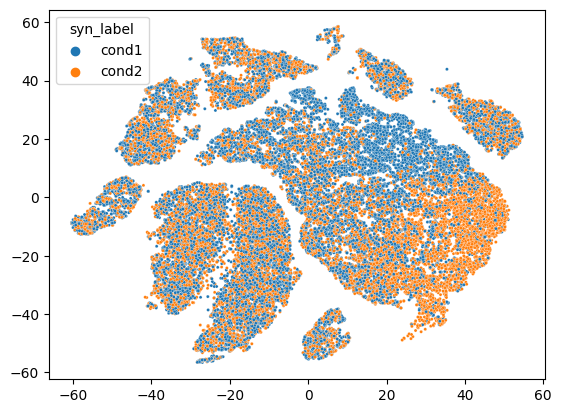

In [7]:
d = d_train.copy()
d.obs['pac_pred'] = 0
d.obs['pac_pred'][pasc.anchor_pac_pos_bool] = 1
d.obs['pac_pred'][pasc.anchor_pac_neg_bool] = -1
sns.scatterplot(x=d.obs.tsne1.values, y=d.obs.tsne2.values, hue=d.obs[phenotype_name], s=5)

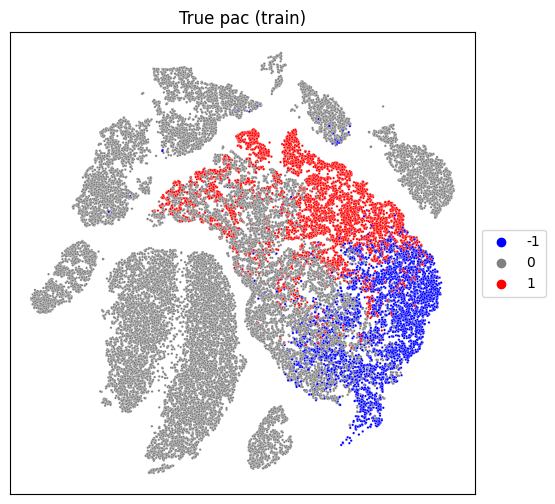

In [8]:
plot_pac(x=d.obs.tsne1.values, y=d.obs.tsne2.values, pac=d.obs['grd'].map({'neg':-1, 'unk':0, 'pos':1}).values.astype(int), title='True pac (train)')

In [57]:
d = d_train.copy()
d.obs['pac_pred'] = 0
d.obs['pac_pred'][pasc.anchor_pac_pos_bool] = 1
d.obs['pac_pred'][pasc.anchor_pac_neg_bool] = -1

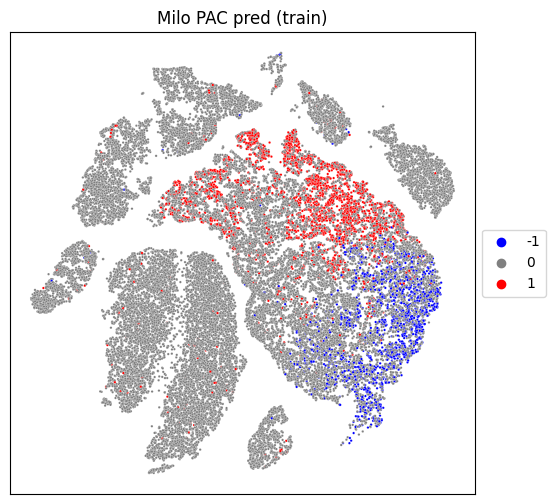

In [60]:
plot_pac(x=d.obs.tsne1.values, y=d.obs.tsne2.values, pac=d.obs['pac_pred'].values, title='Milo PAC pred (train)')

In [62]:
d = d_test.copy()
d.obs['pac_pred'] = 0
d.obs['pac_pred'][pac_pred_pos] = 1
d.obs['pac_pred'][pac_pred_neg] = -1

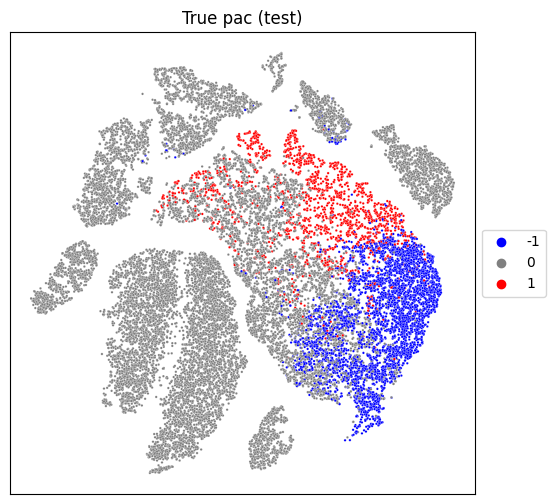

In [63]:
plot_pac(x=d.obs.tsne1.values, y=d.obs.tsne2.values, pac=d.obs['grd'].map({'neg':-1, 'unk':0, 'pos':1}).values.astype(int), title='True pac (test)')

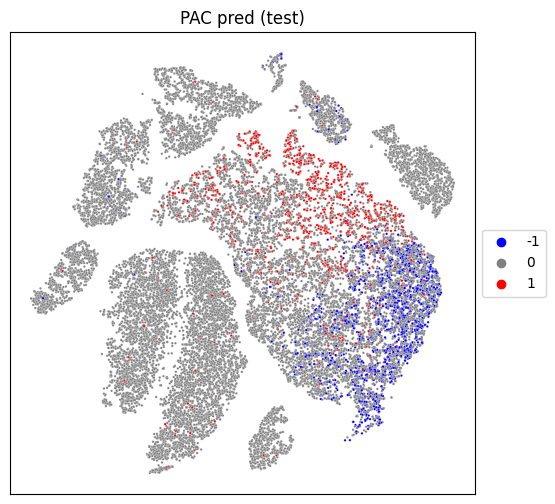

In [64]:
plot_pac(x=d.obs.tsne1.values, y=d.obs.tsne2.values, pac=d.obs['pac_pred'].values, title='PAC pred (test)')

<Axes: >

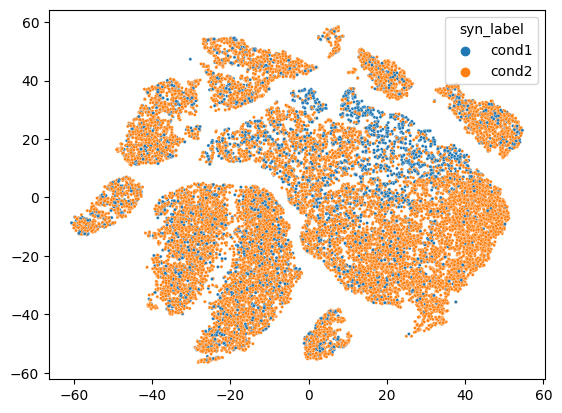

In [65]:
sns.scatterplot(x=d.obs.tsne1.values, y=d.obs.tsne2.values, hue=d.obs[phenotype_name], s=5)

In [66]:
evaluate_pac_prediction(mode='directional', input_is_index=True, 
                        pac_pred_pos=np.where(pac_pred_pos==1)[0],
                        pac_pred_neg=np.where(pac_pred_neg==1)[0],
                        pac_true_pos=np.where(d.obs['grd'].map({'neg':-1, 'unk':0, 'pos':1})==1)[0],
                        pac_true_neg=np.where(d.obs['grd'].map({'neg':-1, 'unk':0, 'pos':1})==-1)[0],
                        cell_names=d.obs.index.values,
                        )

Recall pos:  0.43956043956043955
Precision pos:  0.6998158379373849
F-1 score pos:  0.5399644760213144
Recall neg:  0.2846917570999769
Precision neg:  0.8592334494773519
F-1 score neg:  0.42767950052029136


(0.43956043956043955,
 0.6998158379373849,
 0.5399644760213144,
 0.2846917570999769,
 0.8592334494773519,
 0.42767950052029136)